# CAPSTOP PROJECT: Customer Review Sentiment Analysis using BERT
## AI/ML Specialization Capstone Project

**By:** Vaibhav Krishnakant Chavan, Program: PGDSAIML Batch-1

This notebook demonstrates an end-to-end sentiment analysis pipeline:
1. Data Loading & Exploration (IMDb Dataset)
2. Text Preprocessing
3. Baseline Model (TF-IDF + Logistic Regression)
4. Advanced Model (DistilBERT Fine-tuning)
5. Model Evaluation & Comparison
6. Error Analysis
7. Model Saving for Deployment

**Dataset:** IMDb Large Movie Review Dataset (50K reviews)  
**Source:** https://huggingface.co/datasets/stanfordnlp/imdb

## 1. Environment Setup

In [1]:
# Install required packages (uncomment if running on Colab)
# Note: We do NOT install torch/torchvision here because Colab already has optimized versions pre-installed.
!pip install datasets transformers evaluate accelerate scikit-learn -q
!pip install matplotlib seaborn wordcloud -q
!pip uninstall -y torchvision torchaudio
!pip install datasets transformers evaluate accelerate scikit-learn wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import time
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)
from sklearn.model_selection import train_test_split

# Hugging Face
from datasets import load_dataset
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
import evaluate
import torch

print('All libraries imported successfully!')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

All libraries imported successfully!
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 3. Load the IMDb Dataset

The IMDb dataset contains 50,000 movie reviews labeled as positive or negative.

In [3]:
print('Loading IMDb dataset from Hugging Face...')
dataset = load_dataset('stanfordnlp/imdb')

print(f'\nDataset structure:')
print(dataset)
print(f'\nTraining samples: {len(dataset["train"])}')
print(f'Test samples: {len(dataset["test"])}')
print(f'\nLabel mapping: 0 = Negative, 1 = Positive')

Loading IMDb dataset from Hugging Face...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Training samples: 25000
Test samples: 25000

Label mapping: 0 = Negative, 1 = Positive


## 4. Convert to Pandas DataFrames for EDA

In [4]:
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print('Training set shape:', train_df.shape)
print('Test set shape:', test_df.shape)
print('\nSample records:')
train_df.head()

Training set shape: (25000, 2)
Test set shape: (25000, 2)

Sample records:


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


## 5. Exploratory Data Analysis (EDA)

In [5]:
print('=' * 60)
print('EXPLORATORY DATA ANALYSIS')
print('=' * 60)

# Label distribution
print('\n--- Label Distribution (Training Set) ---')
print(train_df['label'].value_counts())
print(f'\nPositive reviews: {(train_df["label"]==1).sum()} ({(train_df["label"]==1).mean()*100:.1f}%)')
print(f'Negative reviews: {(train_df["label"]==0).sum()} ({(train_df["label"]==0).mean()*100:.1f}%)')

# Text length analysis
train_df['text_length'] = train_df['text'].apply(len)
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

print('\n--- Text Length Statistics ---')
print(train_df[['text_length', 'word_count']].describe())

EXPLORATORY DATA ANALYSIS

--- Label Distribution (Training Set) ---
label
0    12500
1    12500
Name: count, dtype: int64

Positive reviews: 12500 (50.0%)
Negative reviews: 12500 (50.0%)

--- Text Length Statistics ---
       text_length    word_count
count  25000.00000  25000.000000
mean    1325.06964    233.787200
std     1003.13367    173.733032
min       52.00000     10.000000
25%      702.00000    127.000000
50%      979.00000    174.000000
75%     1614.00000    284.000000
max    13704.00000   2470.000000


## 6. EDA Visualizations

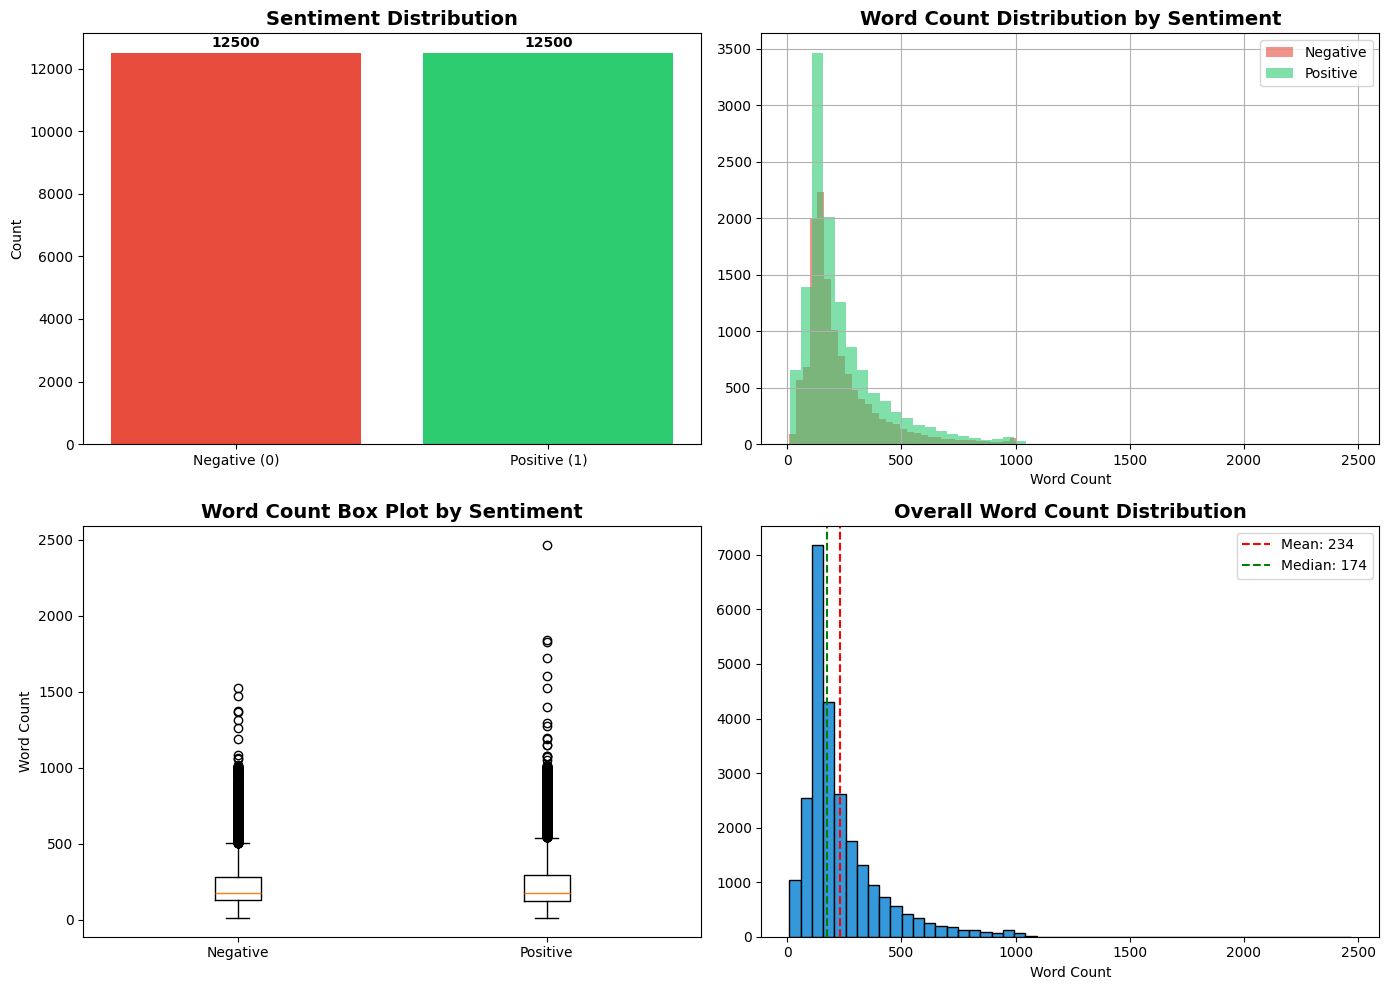

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Label Distribution
labels = ['Negative (0)', 'Positive (1)']
counts = train_df['label'].value_counts().sort_index()
axes[0, 0].bar(labels, counts.values, color=['#e74c3c', '#2ecc71'])
axes[0, 0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Plot 2: Word Count Distribution by Sentiment
train_df[train_df['label']==0]['word_count'].hist(
    bins=50, alpha=0.6, label='Negative', color='#e74c3c', ax=axes[0, 1])
train_df[train_df['label']==1]['word_count'].hist(
    bins=50, alpha=0.6, label='Positive', color='#2ecc71', ax=axes[0, 1])
axes[0, 1].set_title('Word Count Distribution by Sentiment', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].legend()

# Plot 3: Text Length Box Plot
axes[1, 0].boxplot([
    train_df[train_df['label']==0]['word_count'],
    train_df[train_df['label']==1]['word_count']
], labels=['Negative', 'Positive'])
axes[1, 0].set_title('Word Count Box Plot by Sentiment', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Word Count')

# Plot 4: Review Length Histogram
axes[1, 1].hist(train_df['word_count'], bins=50, color='#3498db', edgecolor='black')
axes[1, 1].axvline(train_df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {train_df["word_count"].mean():.0f}')
axes[1, 1].axvline(train_df['word_count'].median(), color='green', linestyle='--', label=f'Median: {train_df["word_count"].median():.0f}')
axes[1, 1].set_title('Overall Word Count Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Word Cloud Visualization

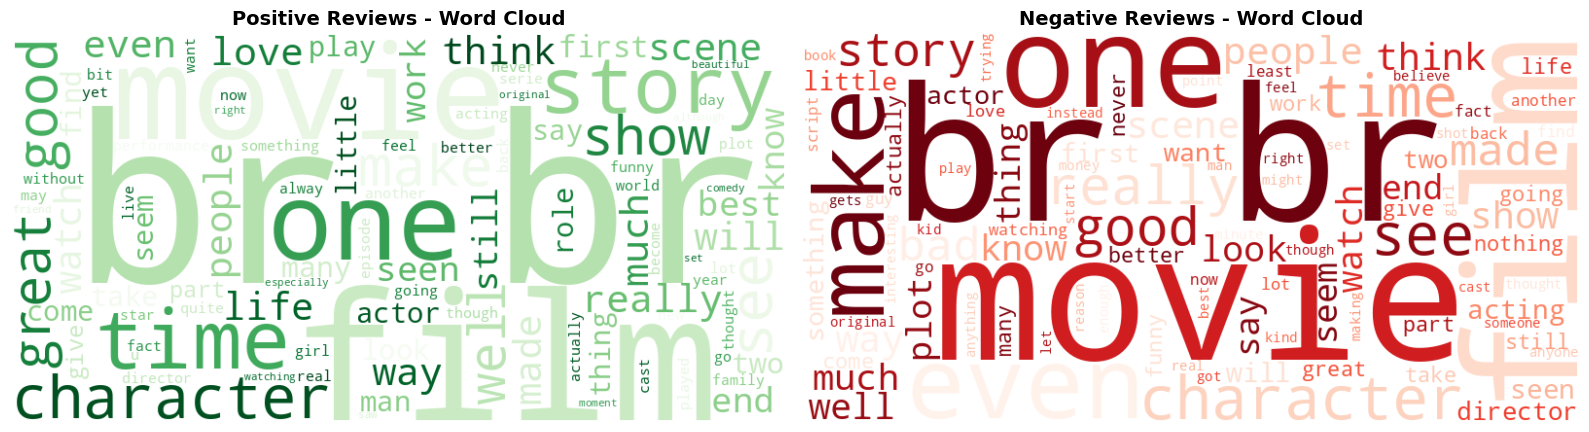

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive reviews word cloud
positive_text = ' '.join(train_df[train_df['label']==1]['text'].values[:5000])
if len(positive_text.strip()) > 0:
    wc_pos = WordCloud(width=800, height=400, background_color='white',
                       colormap='Greens', max_words=100).generate(positive_text)
    axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews - Word Cloud', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Negative reviews word cloud
negative_text = ' '.join(train_df[train_df['label']==0]['text'].values[:5000])
if len(negative_text.strip()) > 0:
    wc_neg = WordCloud(width=800, height=400, background_color='white',
                       colormap='Reds', max_words=100).generate(negative_text)
    axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews - Word Cloud', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Data Quality Checks

In [8]:
print('=' * 60)
print('DATA QUALITY CHECKS')
print('=' * 60)

print(f'\nMissing values in training set:')
print(train_df.isnull().sum())

print(f'\nDuplicate reviews in training set: {train_df.duplicated(subset=["text"]).sum()}')

# Check for HTML tags
html_pattern = re.compile(r'<[^>]+>')
html_count = train_df['text'].apply(lambda x: bool(html_pattern.search(x))).sum()
print(f'Reviews containing HTML tags: {html_count}')

# Sample review with HTML
if html_count > 0:
    sample_html = train_df[train_df['text'].apply(lambda x: bool(html_pattern.search(x)))].iloc[0]['text'][:200]
    print(f'\nSample review with HTML:\n{sample_html}...')

DATA QUALITY CHECKS

Missing values in training set:
text           0
label          0
text_length    0
word_count     0
dtype: int64

Duplicate reviews in training set: 96
Reviews containing HTML tags: 14667

Sample review with HTML:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...


## 9. Text Preprocessing

In [9]:
def preprocess_text(text):
    """Clean text for baseline model."""
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters (keep alphanumeric and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing
print('Preprocessing text data...')
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)

print('Sample original vs cleaned text:')
print(f'\nOriginal: {train_df["text"].iloc[0][:200]}...')
print(f'\nCleaned: {train_df["clean_text"].iloc[0][:200]}...')

Preprocessing text data...
Sample original vs cleaned text:

Original: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...

Cleaned: i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by us customs if it ever tried ...


## 10. Create Train-Validation Split

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df['clean_text'],
    train_df['label'],
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

X_test = test_df['clean_text']
y_test = test_df['label']

print(f'Training samples: {len(X_train)}')
print(f'Validation samples: {len(X_val)}')
print(f'Test samples: {len(X_test)}')

Training samples: 20000
Validation samples: 5000
Test samples: 25000


## 11. Baseline Model: TF-IDF + Logistic Regression

This serves as our baseline to compare against the transformer model.

In [11]:
print('=' * 60)
print('BASELINE MODEL: TF-IDF + LOGISTIC REGRESSION')
print('=' * 60)

# TF-IDF Vectorization
print('\nFitting TF-IDF vectorizer...')
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f'TF-IDF matrix shape: {X_train_tfidf.shape}')

# Logistic Regression
print('\nTraining Logistic Regression model...')
start_time = time.time()

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)

baseline_train_time = time.time() - start_time
print(f'Training time: {baseline_train_time:.2f} seconds')

# Predictions
start_time = time.time()
y_val_pred_baseline = lr_model.predict(X_val_tfidf)
y_val_prob_baseline = lr_model.predict_proba(X_val_tfidf)[:, 1]
baseline_inference_time = (time.time() - start_time) / len(X_val)

y_test_pred_baseline = lr_model.predict(X_test_tfidf)
y_test_prob_baseline = lr_model.predict_proba(X_test_tfidf)[:, 1]

BASELINE MODEL: TF-IDF + LOGISTIC REGRESSION

Fitting TF-IDF vectorizer...
TF-IDF matrix shape: (20000, 50000)

Training Logistic Regression model...
Training time: 2.50 seconds


## 12. Baseline Model Evaluation

In [12]:
print('\n--- Baseline Model: Validation Set Results ---')
print(classification_report(y_val, y_val_pred_baseline, target_names=['Negative', 'Positive']))

print('\n--- Baseline Model: Test Set Results ---')
print(classification_report(y_test, y_test_pred_baseline, target_names=['Negative', 'Positive']))

baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred_baseline),
    'Precision': precision_score(y_test, y_test_pred_baseline),
    'Recall': recall_score(y_test, y_test_pred_baseline),
    'F1-Score': f1_score(y_test, y_test_pred_baseline),
    'ROC-AUC': roc_auc_score(y_test, y_test_prob_baseline),
    'Inference Time (ms/sample)': baseline_inference_time * 1000
}

print('\nBaseline Model Metrics:')
for metric, value in baseline_metrics.items():
    print(f'  {metric}: {value:.4f}')


--- Baseline Model: Validation Set Results ---
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90      2500
    Positive       0.89      0.90      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000


--- Baseline Model: Test Set Results ---
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89     12500
    Positive       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000


Baseline Model Metrics:
  Accuracy: 0.8932
  Precision: 0.8882
  Recall: 0.8996
  F1-Score: 0.8938
  ROC-AUC: 0.9597
  Inference Time (ms/sample): 0.0032


## 13. Advanced Model: DistilBERT Fine-tuning

DistilBERT is a smaller, faster version of BERT that retains 97% of BERT's language understanding while being 60% faster.

In [13]:
print('=' * 60)
print('ADVANCED MODEL: DistilBERT FINE-TUNING')
print('=' * 60)

# Load tokenizer
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
print(f'\nModel: {MODEL_NAME}')
print(f'Vocabulary size: {tokenizer.vocab_size}')

ADVANCED MODEL: DistilBERT FINE-TUNING


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Model: distilbert-base-uncased
Vocabulary size: 30522


## 14. Tokenize Dataset for DistilBERT

In [14]:
MAX_LENGTH = 256  # Truncate/pad to 256 tokens

def tokenize_function(examples):
    """Tokenize text for DistilBERT."""
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

print(f'Tokenizing dataset (max_length={MAX_LENGTH})...')

# Tokenize the dataset
tokenized_train = dataset['train'].map(tokenize_function, batched=True)
tokenized_test = dataset['test'].map(tokenize_function, batched=True)

# Create train-validation split
train_val_split = tokenized_train.train_test_split(test_size=0.2, seed=42)
tokenized_train_split = train_val_split['train']
tokenized_val_split = train_val_split['test']

print(f'Tokenized training samples: {len(tokenized_train_split)}')
print(f'Tokenized validation samples: {len(tokenized_val_split)}')
print(f'Tokenized test samples: {len(tokenized_test)}')

# Set format for PyTorch
tokenized_train_split.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_val_split.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

Tokenizing dataset (max_length=256)...


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Tokenized training samples: 20000
Tokenized validation samples: 5000
Tokenized test samples: 25000


## 15. Load DistilBERT Model

In [15]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Total parameters: 66,955,010
Trainable parameters: 66,955,010


## 16. Define Training Arguments & Metrics

In [16]:
# Load evaluation metric
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    """Compute metrics for evaluation."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    prec = precision_score(labels, predictions)
    rec = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)
    return {
        'accuracy': acc['accuracy'],
        'precision': prec,
        'recall': rec,
        'f1': f1
    }

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=42
)

print('Training Configuration:')
print(f'  Epochs: {training_args.num_train_epochs}')
print(f'  Batch size (train): {training_args.per_device_train_batch_size}')
print(f'  Batch size (eval): {training_args.per_device_eval_batch_size}')
print(f'  Learning rate: {training_args.learning_rate}')
print(f'  Weight decay: {training_args.weight_decay}')
print(f'  Warmup steps: {training_args.warmup_steps}')
print(f'  FP16: {training_args.fp16}')

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training Configuration:
  Epochs: 3
  Batch size (train): 16
  Batch size (eval): 32
  Learning rate: 2e-05
  Weight decay: 0.01
  Warmup steps: 500
  FP16: True


## 17. Train DistilBERT Model

**Note:** Training takes approximately 15-30 minutes on a GPU (Google Colab T4).

In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_split,
    eval_dataset=tokenized_val_split,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print('Starting DistilBERT fine-tuning...')
print('This may take 15-30 minutes on a GPU...')

train_result = trainer.train()
print(f'\nTraining completed!')
print(f'Training time: {train_result.metrics["train_runtime"]:.2f} seconds')
print(f'Training loss: {train_result.metrics["train_loss"]:.4f}')

Starting DistilBERT fine-tuning...
This may take 15-30 minutes on a GPU...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.241890,0.316397,0.877000,0.954786,0.792099,0.865867
2,0.190624,0.259427,0.910200,0.904762,0.917398,0.911036
3,0.106296,0.340829,0.911600,0.916129,0.906624,0.911352


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed!
Training time: 474.05 seconds
Training loss: 0.2210


## 18. Evaluate DistilBERT on Test Set

In [18]:
print('--- DistilBERT: Test Set Evaluation ---')

# Get predictions
start_time = time.time()
predictions = trainer.predict(tokenized_test)
bert_total_inference_time = time.time() - start_time

y_test_pred_bert = np.argmax(predictions.predictions, axis=-1)
y_test_prob_bert = torch.softmax(torch.tensor(predictions.predictions), dim=-1)[:, 1].numpy()

bert_inference_time = bert_total_inference_time / len(tokenized_test)

print(classification_report(y_test, y_test_pred_bert, target_names=['Negative', 'Positive']))

bert_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred_bert),
    'Precision': precision_score(y_test, y_test_pred_bert),
    'Recall': recall_score(y_test, y_test_pred_bert),
    'F1-Score': f1_score(y_test, y_test_pred_bert),
    'ROC-AUC': roc_auc_score(y_test, y_test_prob_bert),
    'Inference Time (ms/sample)': bert_inference_time * 1000
}

print('\nDistilBERT Model Metrics:')
for metric, value in bert_metrics.items():
    print(f'  {metric}: {value:.4f}')

--- DistilBERT: Test Set Evaluation ---


              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91     12500
    Positive       0.91      0.92      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000


DistilBERT Model Metrics:
  Accuracy: 0.9122
  Precision: 0.9094
  Recall: 0.9155
  F1-Score: 0.9125
  ROC-AUC: 0.9714
  Inference Time (ms/sample): 2.1710


## 19. Model Comparison

In [19]:
print('\n' + '=' * 60)
print('MODEL COMPARISON')
print('=' * 60)

comparison_df = pd.DataFrame({
    'Metric': list(baseline_metrics.keys()),
    'TF-IDF + LR (Baseline)': list(baseline_metrics.values()),
    'DistilBERT (Advanced)': list(bert_metrics.values())
})

comparison_df['Improvement'] = comparison_df['DistilBERT (Advanced)'] - comparison_df['TF-IDF + LR (Baseline)']
print('\n')
comparison_df


MODEL COMPARISON




,Metric,TF-IDF + LR (Baseline),DistilBERT (Advanced),Improvement
0,Accuracy,0.893160,0.912160,0.019000
1,Precision,0.888160,0.909409,0.021248
2,Recall,0.899600,0.915520,0.015920
3,F1-Score,0.893844,0.912454,0.018611
4,ROC-AUC,0.959662,0.971390,0.011729
5,Inference Time (ms/sample),0.003220,2.171044,2.167824


## 20. Visualization - Model Comparison

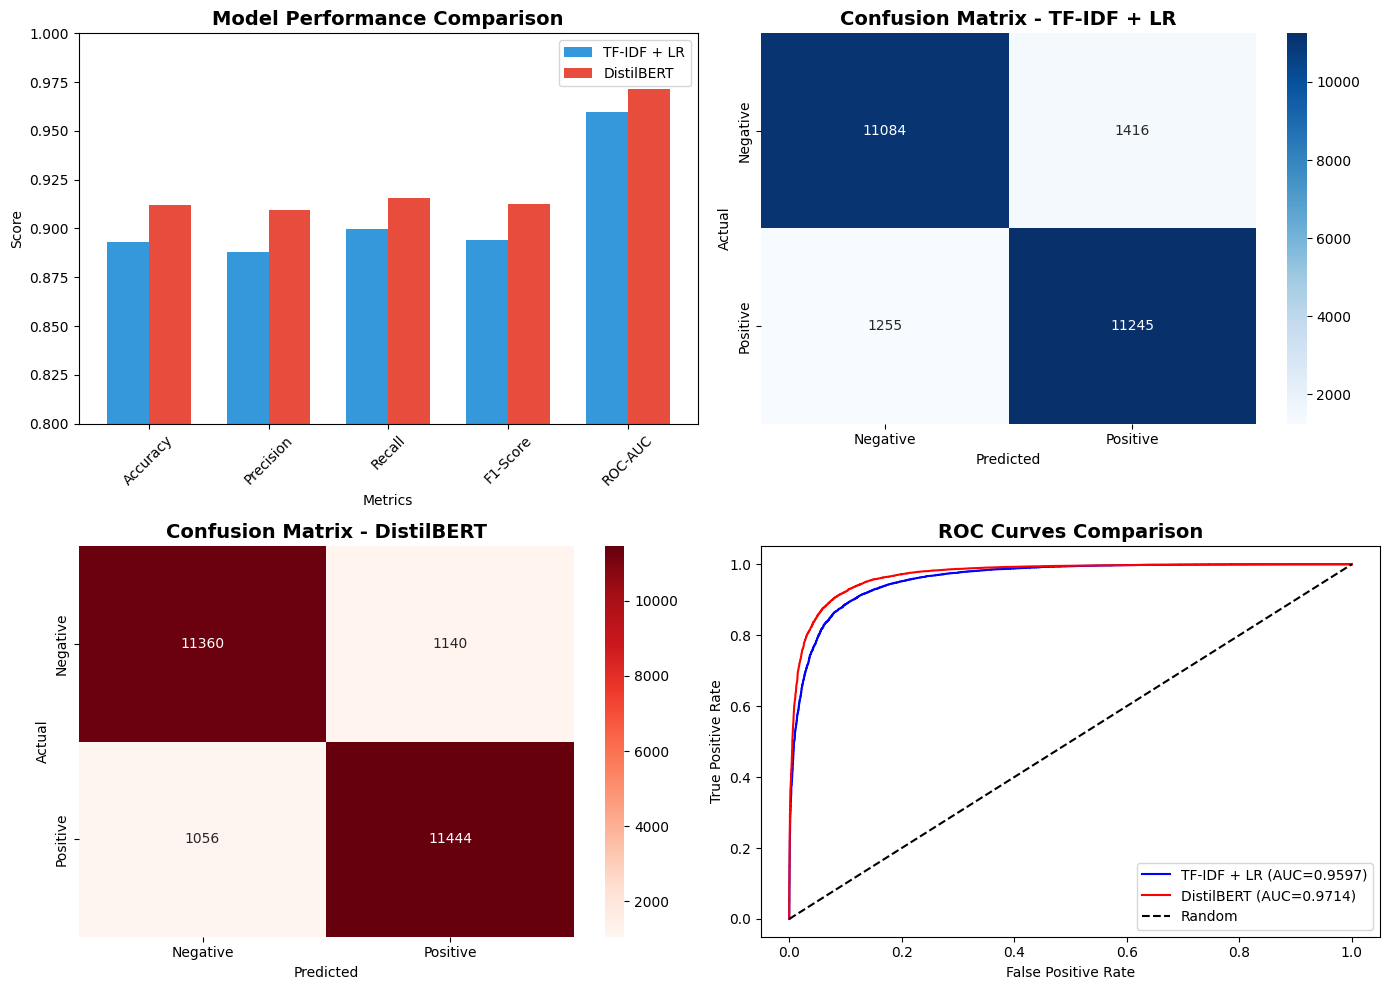

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Metrics Comparison Bar Chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
baseline_vals = [baseline_metrics[m] for m in metrics_to_plot]
bert_vals = [bert_metrics[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35

bars1 = axes[0, 0].bar(x - width/2, baseline_vals, width, label='TF-IDF + LR', color='#3498db')
bars2 = axes[0, 0].bar(x + width/2, bert_vals, width, label='DistilBERT', color='#e74c3c')
axes[0, 0].set_xlabel('Metrics')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics_to_plot, rotation=45)
axes[0, 0].legend()
axes[0, 0].set_ylim(0.8, 1.0)

# Plot 2: Confusion Matrix - Baseline
cm_baseline = confusion_matrix(y_test, y_test_pred_baseline)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0, 1].set_title('Confusion Matrix - TF-IDF + LR', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Plot 3: Confusion Matrix - DistilBERT
cm_bert = confusion_matrix(y_test, y_test_pred_bert)
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Reds', ax=axes[1, 0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[1, 0].set_title('Confusion Matrix - DistilBERT', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# Plot 4: ROC Curves
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_test_prob_baseline)
fpr_bert, tpr_bert, _ = roc_curve(y_test, y_test_prob_bert)

axes[1, 1].plot(fpr_baseline, tpr_baseline, 'b-', label=f'TF-IDF + LR (AUC={baseline_metrics["ROC-AUC"]:.4f})')
axes[1, 1].plot(fpr_bert, tpr_bert, 'r-', label=f'DistilBERT (AUC={bert_metrics["ROC-AUC"]:.4f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 21. Error Analysis

In [21]:
print('=' * 60)
print('ERROR ANALYSIS')
print('=' * 60)

# Find misclassified samples by DistilBERT
test_texts = dataset['test']['text']
test_labels = dataset['test']['label']

errors_idx = np.where(y_test_pred_bert != np.array(test_labels))[0]
print(f'\nTotal misclassified samples: {len(errors_idx)} out of {len(test_labels)}')
print(f'Error rate: {len(errors_idx)/len(test_labels)*100:.2f}%')

# Show sample errors
print('\n--- Sample Misclassified Reviews ---')
for i, idx in enumerate(errors_idx[:5]):
    idx = int(idx)  # Convert numpy int to native python int for dataset indexing
    print(f'\n{"="*40}')
    print(f'Error {i+1}:')
    print(f'  True Label: {"Positive" if test_labels[idx]==1 else "Negative"}')
    print(f'  Predicted: {"Positive" if y_test_pred_bert[idx]==1 else "Negative"}')
    print(f'  Confidence: {max(y_test_prob_bert[idx], 1-y_test_prob_bert[idx]):.4f}')
    print(f'  Review (first 200 chars): {test_texts[idx][:200]}...')

# Error analysis by review length
error_lengths = [len(test_texts[int(idx)].split()) for idx in errors_idx]
correct_idx = np.where(y_test_pred_bert == np.array(test_labels))[0]
correct_lengths = [len(test_texts[int(idx)].split()) for idx in correct_idx]

print(f'\nAverage word count - Misclassified: {np.mean(error_lengths):.0f}')
print(f'Average word count - Correctly classified: {np.mean(correct_lengths):.0f}')

# Confidence distribution for errors
error_confidences = [max(y_test_prob_bert[idx], 1-y_test_prob_bert[idx]) for idx in errors_idx]
print(f'\nMean confidence on errors: {np.mean(error_confidences):.4f}')
print(f'Mean confidence on correct: {np.mean([max(y_test_prob_bert[idx], 1-y_test_prob_bert[idx]) for idx in correct_idx]):.4f}')

ERROR ANALYSIS

Total misclassified samples: 2196 out of 25000
Error rate: 8.78%

--- Sample Misclassified Reviews ---

Error 1:
  True Label: Negative
  Predicted: Positive
  Confidence: 0.9941
  Review (first 200 chars): First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy thes...

Error 2:
  True Label: Negative
  Predicted: Positive
  Confidence: 0.9975
  Review (first 200 chars): Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His father, (Nicholas Farrell), is a vicar and his mother, (Laura Linney), is ... well, let's just say sh...

Error 3:
  True Label: Negative
  Predicted: Positive
  Confidence: 0.9924
  Review (first 200 chars): Low budget horror movie. If you don't raise your expectations too high, you'll probably enjoy this little flick. Beginning and end are pretty good, middle drags 

## 22. Training History Visualization

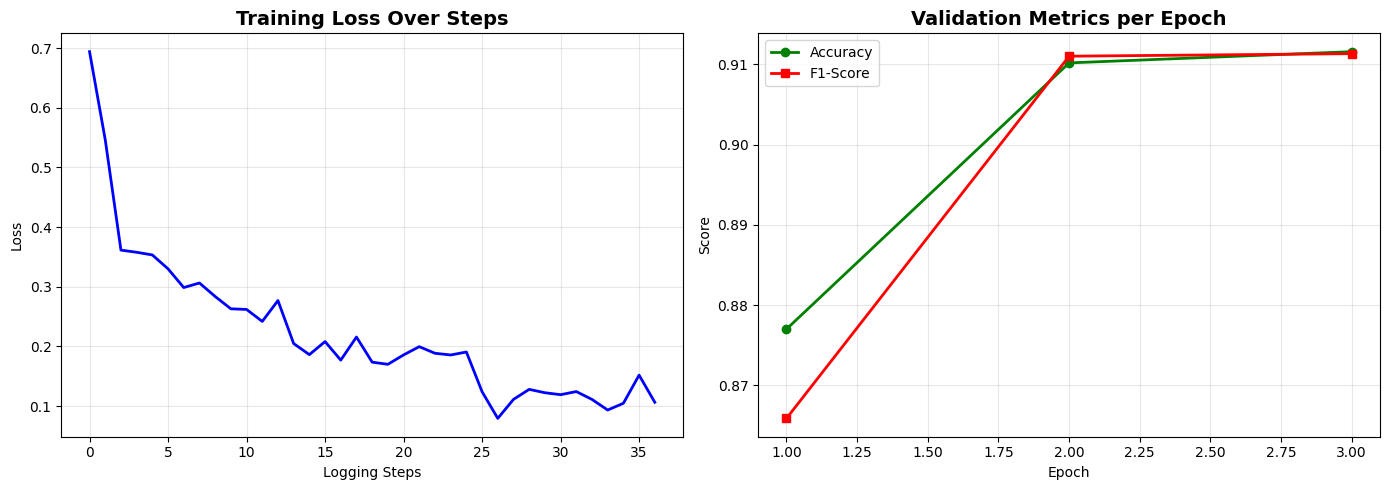

In [22]:
# Extract training history
training_history = trainer.state.log_history

train_losses = [x['loss'] for x in training_history if 'loss' in x]
eval_metrics_hist = [x for x in training_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Loss
axes[0].plot(train_losses, 'b-', linewidth=2)
axes[0].set_title('Training Loss Over Steps', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Logging Steps')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Validation Metrics per Epoch
if eval_metrics_hist:
    epochs = range(1, len(eval_metrics_hist) + 1)
    eval_acc = [x.get('eval_accuracy', 0) for x in eval_metrics_hist]
    eval_f1_hist = [x.get('eval_f1', 0) for x in eval_metrics_hist]

    axes[1].plot(epochs, eval_acc, 'g-o', label='Accuracy', linewidth=2)
    axes[1].plot(epochs, eval_f1_hist, 'r-s', label='F1-Score', linewidth=2)
    axes[1].set_title('Validation Metrics per Epoch', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 23. Save Model for Deployment

In [23]:
print('Saving fine-tuned model...')
model_save_path = './sentiment_model'
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f'Model saved to: {model_save_path}')

# For Google Drive (Colab)
# from google.colab import drive
# drive.mount('/content/drive')
# !cp -r ./sentiment_model /content/drive/MyDrive/sentiment_model

Saving fine-tuned model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./sentiment_model


## 24. Inference Function (for Deployment)

In [24]:
def predict_sentiment(text, model, tokenizer, device='cpu'):
    """
    Predict sentiment for a given text.
    Returns: label (str), confidence (float)
    """
    model.eval()
    model.to(device)

    inputs = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][prediction].item()

    label = 'Positive' if prediction == 1 else 'Negative'
    return label, confidence

# Test predictions
print('--- Sample Predictions ---')
sample_reviews = [
    'This movie was absolutely fantastic! The acting was superb and the plot kept me engaged throughout.',
    'Terrible waste of time. The story made no sense and the acting was wooden.',
    'It was okay, nothing special. Some parts were good but overall mediocre.',
    "I've never seen anything so beautiful. This film changed my perspective on life.",
    'The worst movie I have ever seen. I walked out after 30 minutes.'
]

device = 'cuda' if torch.cuda.is_available() else 'cpu'
for review in sample_reviews:
    label, confidence = predict_sentiment(review, model, tokenizer, device)
    print(f'\n  Review: {review[:80]}...')
    print(f'  Prediction: {label} (Confidence: {confidence:.4f})')

--- Sample Predictions ---

  Review: This movie was absolutely fantastic! The acting was superb and the plot kept me ...
  Prediction: Positive (Confidence: 0.9976)

  Review: Terrible waste of time. The story made no sense and the acting was wooden....
  Prediction: Negative (Confidence: 0.9981)

  Review: It was okay, nothing special. Some parts were good but overall mediocre....
  Prediction: Negative (Confidence: 0.9947)

  Review: I've never seen anything so beautiful. This film changed my perspective on life....
  Prediction: Positive (Confidence: 0.9967)

  Review: The worst movie I have ever seen. I walked out after 30 minutes....
  Prediction: Negative (Confidence: 0.9977)


## 25. Known Failure Cases

These examples demonstrate limitations of the model with sarcastic or mixed-sentiment reviews.

In [25]:
print('--- Known Failure Cases ---')
failure_cases = [
    'Oh great, another superhero movie. Just what we needed. The special effects were amazing though, I will give them that.',
    'I laughed so hard at this movie - not because it was funny, but because it was so bad it became entertaining.',
    'The movie was not bad, not good, just... there. Like wallpaper.'
]

print('\nThese reviews contain sarcasm or mixed sentiment that may confuse the model:')
for review in failure_cases:
    label, confidence = predict_sentiment(review, model, tokenizer, device)
    print(f'\n  Review: {review}')
    print(f'  Prediction: {label} (Confidence: {confidence:.4f})')
    print(f'  Note: This may be a misclassification due to sarcasm/mixed signals')

--- Known Failure Cases ---

These reviews contain sarcasm or mixed sentiment that may confuse the model:

  Review: Oh great, another superhero movie. Just what we needed. The special effects were amazing though, I will give them that.
  Prediction: Positive (Confidence: 0.8961)
  Note: This may be a misclassification due to sarcasm/mixed signals

  Review: I laughed so hard at this movie - not because it was funny, but because it was so bad it became entertaining.
  Prediction: Negative (Confidence: 0.9793)
  Note: This may be a misclassification due to sarcasm/mixed signals

  Review: The movie was not bad, not good, just... there. Like wallpaper.
  Prediction: Negative (Confidence: 0.9962)
  Note: This may be a misclassification due to sarcasm/mixed signals


## 26. Project Summary

In [26]:
print('=' * 60)
print('PROJECT SUMMARY')
print('=' * 60)
print(f'''
Dataset: IMDb Large Movie Review Dataset (50,000 reviews)
Task: Binary Sentiment Classification (Positive/Negative)

Models Trained:
  1. Baseline: TF-IDF + Logistic Regression
     - Accuracy: {baseline_metrics['Accuracy']:.4f}
     - F1-Score: {baseline_metrics['F1-Score']:.4f}
     - ROC-AUC: {baseline_metrics['ROC-AUC']:.4f}

  2. Advanced: DistilBERT (fine-tuned)
     - Accuracy: {bert_metrics['Accuracy']:.4f}
     - F1-Score: {bert_metrics['F1-Score']:.4f}
     - ROC-AUC: {bert_metrics['ROC-AUC']:.4f}

Improvement: +{(bert_metrics['Accuracy'] - baseline_metrics['Accuracy'])*100:.2f}% accuracy

Key Findings:
  - DistilBERT outperforms the baseline across all metrics
  - The model struggles with sarcastic and mixed-sentiment reviews
  - Longer reviews tend to have slightly higher error rates due to truncation
  - The model is ready for deployment via Streamlit/FastAPI

Deployment: Model saved for inference via Streamlit app or FastAPI endpoint
''')

print('Project completed successfully!')

PROJECT SUMMARY

Dataset: IMDb Large Movie Review Dataset (50,000 reviews)
Task: Binary Sentiment Classification (Positive/Negative)

Models Trained:
  1. Baseline: TF-IDF + Logistic Regression
     - Accuracy: 0.8932
     - F1-Score: 0.8938
     - ROC-AUC: 0.9597

  2. Advanced: DistilBERT (fine-tuned)
     - Accuracy: 0.9122
     - F1-Score: 0.9125
     - ROC-AUC: 0.9714

Improvement: +1.90% accuracy

Key Findings:
  - DistilBERT outperforms the baseline across all metrics
  - The model struggles with sarcastic and mixed-sentiment reviews
  - Longer reviews tend to have slightly higher error rates due to truncation
  - The model is ready for deployment via Streamlit/FastAPI

Deployment: Model saved for inference via Streamlit app or FastAPI endpoint

Project completed successfully!
